Loading checkpoint from ../checkpoints/metric-finetune/13.pth...
Loaded checkpoint from epoch 14
Best metrics so far: {'d1': 0.9947128891944885, 'd2': 0.9999884366989136, 'd3': 1.0, 'abs_rel': 0.05785690248012543, 'sq_rel': 2.66656231880188, 'rmse': 31.709012985229492, 'rmse_log': 0.0629655122756958, 'log10': 0.024888837710022926, 'silog': 0.04929092153906822}
(0.6260492765226361, 0.0, 0.0, 0.0) 0.0 1.0
Prediction — min: 447.660  max: 755.144  mean: 545.904
GT depth   — min: 436.100  max: 754.200  valid px: 382871 / 589824


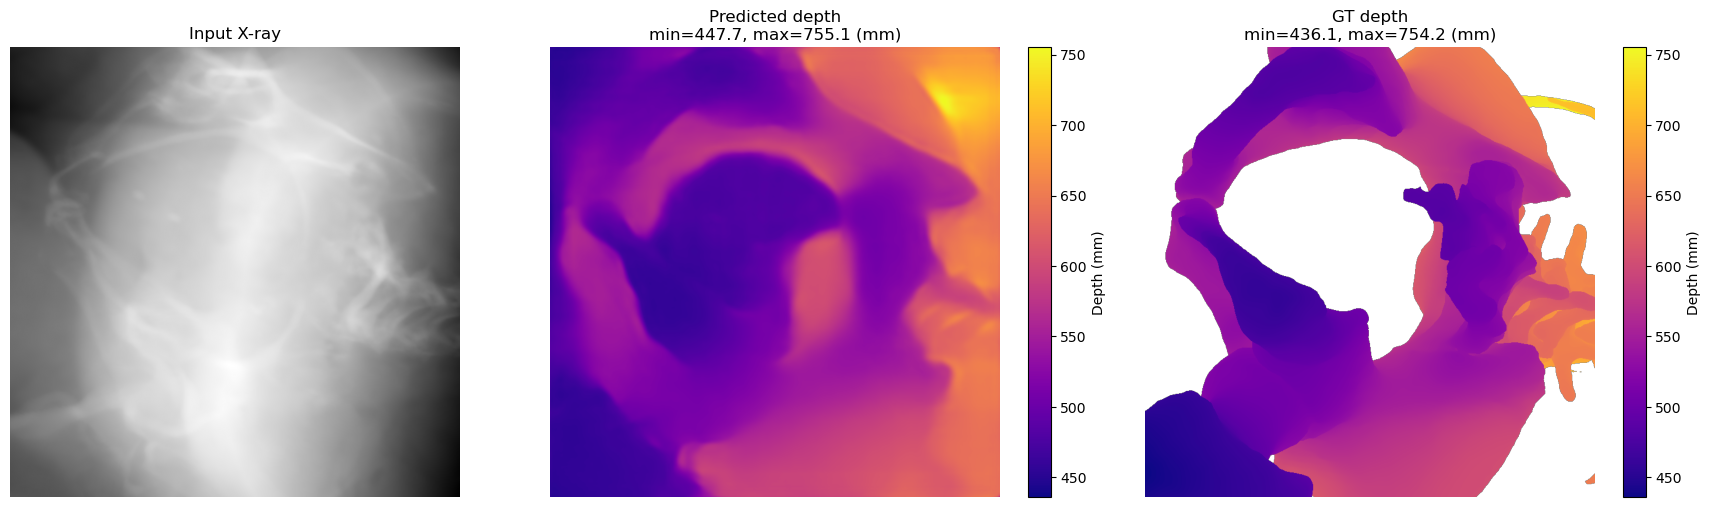

Saved to eval_result.png


In [5]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import Compose
import os

from depth_anything_v2.dpt import DepthAnythingV2
from dataset.transform import Resize, NormalizeImage, PrepareForNet

# ── Config ────────────────────────────────────────────────────────────────────
ENCODER        = "vitl"
CHECKPOINT     = "../checkpoints/metric-finetune/13.pth"
IMAGE_PATH     = "example/xray/1_01_CT_0051.tif"
DEPTH_PATH     = "example/depth/1_01_CT_0051.tif"
MAX_DEPTH      = 1000.0     # must match --max-depth used during training
IMG_SIZE       = 518        # must match --img-size used during training

model_configs = {
    "vits": {"encoder": "vits", "features": 64,  "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

# ── Model ─────────────────────────────────────────────────────────────────────
model = DepthAnythingV2(**{**model_configs[ENCODER], "max_depth": MAX_DEPTH})

if os.path.exists(CHECKPOINT):
    print(f"Loading checkpoint from {CHECKPOINT}...")
    checkpoint = torch.load(CHECKPOINT, map_location="cpu")
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', '?')}")
    print(f"Best metrics so far: {checkpoint.get('previous_best', 'N/A')}")
else:
    print(f"Warning: checkpoint not found at {CHECKPOINT}. Proceeding with random weights.")

model = model.cuda().eval()

# ── Transform (identical to XrayDepth dataset) ────────────────────────────────
transform = Compose([
    Resize(
        width=IMG_SIZE,
        height=IMG_SIZE,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# ── Load & preprocess image ───────────────────────────────────────────────────
raw_image = cv2.imread(IMAGE_PATH, cv2.IMREAD_UNCHANGED)  # (H, W) float32 [0,1]
print(cv2.mean(raw_image), raw_image.min(), raw_image.max())
assert raw_image is not None, f"Could not read image: {IMAGE_PATH}"
assert raw_image.dtype == np.float32, f"Expected float32 TIFF, got {raw_image.dtype}"

image_3ch = np.stack([raw_image, raw_image, raw_image], axis=-1).astype(np.float32)

sample = transform({"image": image_3ch, "depth": np.zeros_like(raw_image)})
img_tensor = torch.from_numpy(sample["image"]).unsqueeze(0).cuda()  # (1, 3, H, W)

# ── Inference ─────────────────────────────────────────────────────────────────
with torch.no_grad():
    pred = model(img_tensor)  # (1, H_net, W_net)

# Upsample prediction back to original image resolution
orig_h, orig_w = raw_image.shape
pred = F.interpolate(
    pred[:, None],
    size=(orig_h, orig_w),
    mode="bilinear",
    align_corners=True,
)[0, 0].cpu().numpy()  # (H, W)

print(f"Prediction — min: {pred.min():.3f}  max: {pred.max():.3f}  mean: {pred.mean():.3f}")

# ── Load GT depth (optional) ──────────────────────────────────────────────────
gt_depth = None
valid = None
if DEPTH_PATH is not None:
    gt_raw = cv2.imread(DEPTH_PATH, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    gt_depth = gt_raw.astype(np.float32) / 10.0  # uint16 → millimetres
    valid = (gt_depth > 0) & (gt_depth <= MAX_DEPTH)
    print(f"GT depth   — min: {gt_depth[valid].min():.3f}  max: {gt_depth[valid].max():.3f}  "
          f"valid px: {valid.sum()} / {valid.size}")

# ── Visualise ─────────────────────────────────────────────────────────────────
ncols = 3 if gt_depth is not None else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

axes[0].imshow(raw_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input X-ray")
axes[0].axis("off")

vmin, vmax = pred.min(), pred.max()
if gt_depth is not None:
    vmin = min(vmin, gt_depth[valid].min())
    vmax = max(vmax, gt_depth[valid].max())

depth_unit = "mm" if MAX_DEPTH > 100 else "m"

im = axes[1].imshow(pred, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Predicted depth\nmin={pred.min():.1f}, max={pred.max():.1f} ({depth_unit})")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label=f"Depth ({depth_unit})")

if gt_depth is not None:
    gt_vis = np.where(valid, gt_depth, np.nan)
    im2 = axes[2].imshow(gt_vis, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[2].set_title(f"GT depth\nmin={gt_depth[valid].min():.1f}, max={gt_depth[valid].max():.1f} ({depth_unit})")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], label=f"Depth ({depth_unit})")

plt.tight_layout()
plt.savefig("eval_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to eval_result.png")

Loading checkpoint from exp/xray-0219/latest.pth...
Loaded epoch 40 | best metrics: {'d1': 0.9962436556816101, 'd2': 0.9999930262565613, 'd3': 1.0, 'abs_rel': 0.05544300749897957, 'sq_rel': 2.4277522563934326, 'rmse': 29.814861297607422, 'rmse_log': 0.05928907170891762, 'log10': 0.023872822523117065, 'silog': 0.04541949927806854}
Selected 5 pairs: ['Pelvic-Ref-023_0200.tif', 'Pelvic-Ref-020_0234.tif', 'Pelvic-Ref-023_0215.tif', '1_05_CT_0133.tif', '1_05_CT_0096.tif']
[1/5] Pelvic-Ref-023_0200.tif — pred [428.8, 597.4] | gt [429.0, 611.8] | abs_err mean=6.9mm
[2/5] Pelvic-Ref-020_0234.tif — pred [443.4, 575.4] | gt [433.3, 586.9] | abs_err mean=3.6mm
[3/5] Pelvic-Ref-023_0215.tif — pred [468.6, 621.9] | gt [460.8, 619.5] | abs_err mean=5.8mm
[4/5] 1_05_CT_0133.tif — pred [380.7, 683.6] | gt [385.7, 690.8] | abs_err mean=5.5mm
[5/5] 1_05_CT_0096.tif — pred [361.6, 640.1] | gt [361.0, 774.4] | abs_err mean=9.1mm


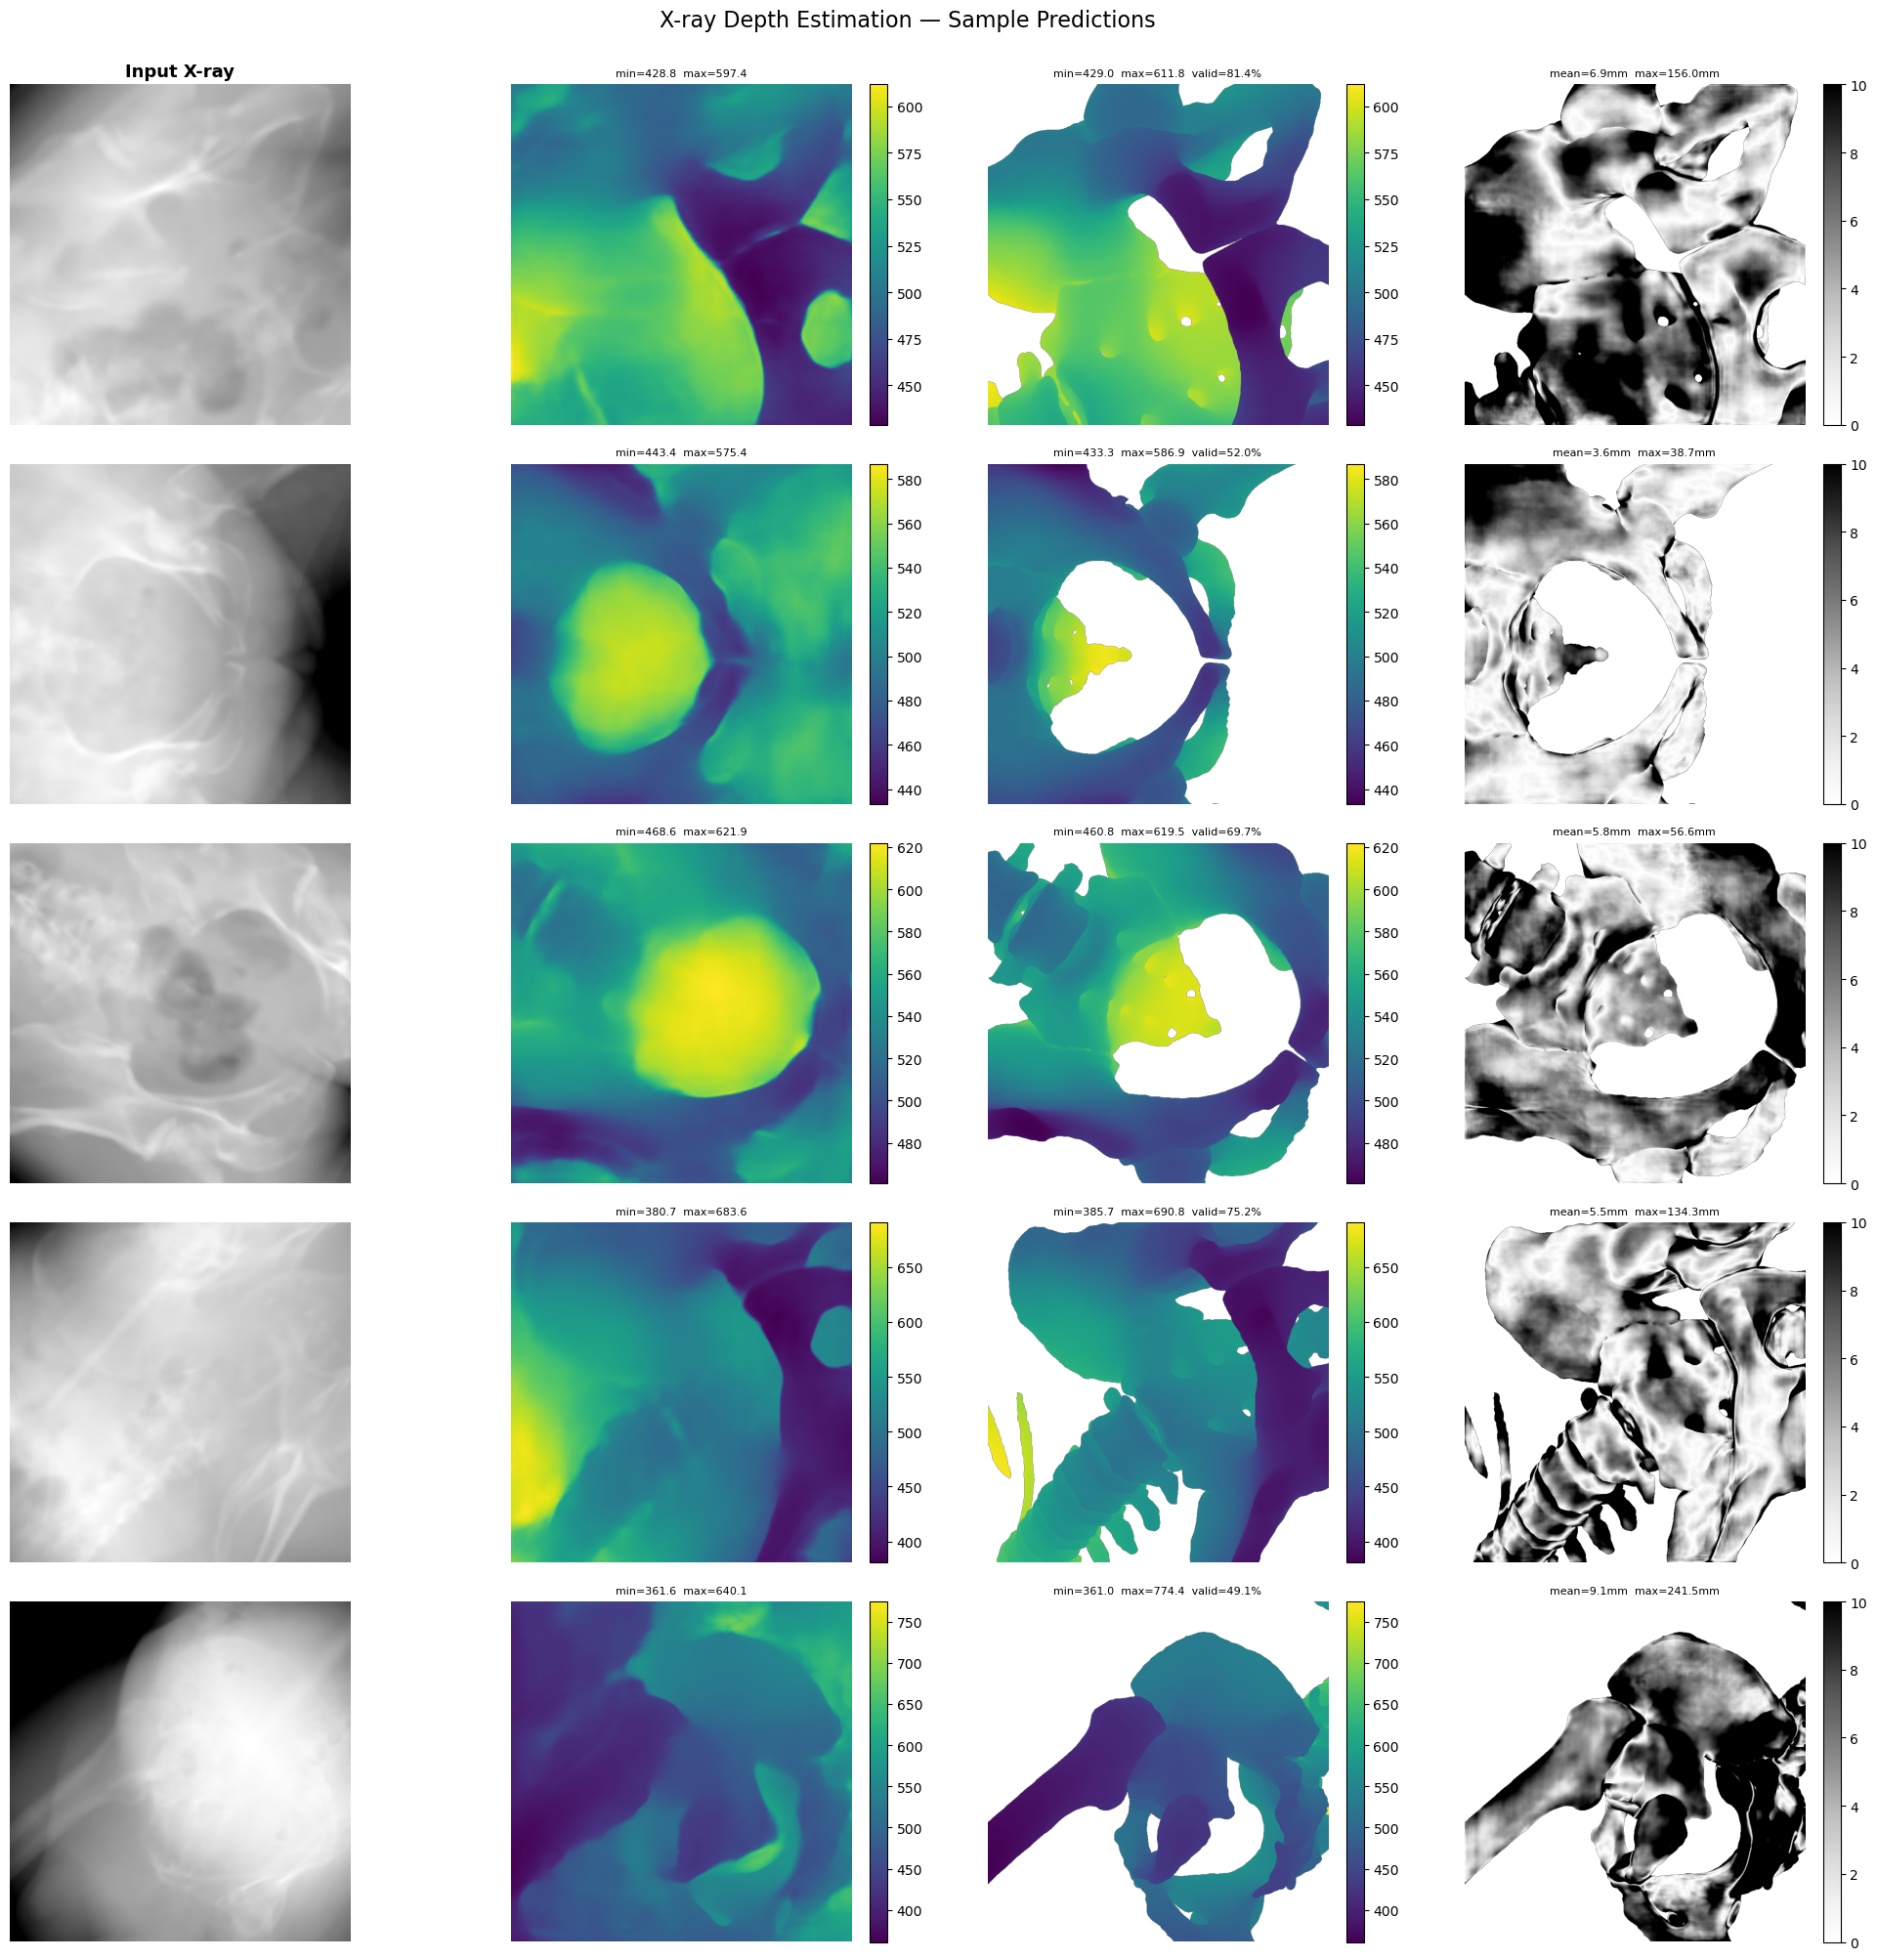


Saved to eval_examples.png


In [12]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import Compose
import os
import random

from depth_anything_v2.dpt import DepthAnythingV2
from dataset.transform import Resize, NormalizeImage, PrepareForNet

# ── Config ────────────────────────────────────────────────────────────────────
ENCODER        = "vitl"
# CHECKPOINT     = "../checkpoints/metric-finetune/13.pth"
CHECKPOINT     = "exp/xray-0219/latest.pth"
IMAGE_DIR      = "/home/jeremy/data/XrayDepthEstScaling/images"
DEPTH_DIR      = "/home/jeremy/data/XrayDepthEstScaling/depths"
MAX_DEPTH      = 1000.0
IMG_SIZE       = 518
N_SAMPLES      = 5
SAVE_PATH      = "eval_examples.png"
SEED           = 42

model_configs = {
    "vits": {"encoder": "vits", "features": 64,  "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

# ── Model ─────────────────────────────────────────────────────────────────────
model = DepthAnythingV2(**{**model_configs[ENCODER], "max_depth": MAX_DEPTH})

if os.path.exists(CHECKPOINT):
    print(f"Loading checkpoint from {CHECKPOINT}...")
    checkpoint = torch.load(CHECKPOINT, map_location="cpu")
    model.load_state_dict(checkpoint["model"])
    print(f"Loaded epoch {checkpoint.get('epoch', '?')} | best metrics: {checkpoint.get('previous_best', 'N/A')}")
else:
    print(f"Warning: checkpoint not found at {CHECKPOINT}. Proceeding with random weights.")

model = model.cuda().eval()

# ── Transform ─────────────────────────────────────────────────────────────────
transform = Compose([
    Resize(
        width=IMG_SIZE,
        height=IMG_SIZE,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# ── Sample pairs ──────────────────────────────────────────────────────────────
all_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".tif") and os.path.exists(os.path.join(DEPTH_DIR, f))
]
assert len(all_files) >= N_SAMPLES, (
    f"Only {len(all_files)} matched pairs found, but N_SAMPLES={N_SAMPLES}."
)

random.seed(SEED)
selected = random.sample(all_files, N_SAMPLES)
print(f"Selected {N_SAMPLES} pairs: {selected}")

# ── Inference helper ──────────────────────────────────────────────────────────
def predict(image_path):
    raw = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    assert raw is not None, f"Could not read: {image_path}"
    assert raw.dtype == np.float32, f"Expected float32 TIFF, got {raw.dtype}"
    image_3ch = np.stack([raw, raw, raw], axis=-1).astype(np.float32)
    sample = transform({"image": image_3ch, "depth": np.zeros_like(raw)})
    img_tensor = torch.from_numpy(sample["image"]).unsqueeze(0).cuda()
    with torch.no_grad():
        pred = model(img_tensor)
    pred = F.interpolate(
        pred[:, None],
        size=raw.shape,
        mode="bilinear",
        align_corners=True,
    )[0, 0].cpu().numpy()
    return raw, pred

def load_gt(depth_path):
    gt_raw = cv2.imread(depth_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    assert gt_raw is not None, f"Could not read: {depth_path}"
    gt = gt_raw.astype(np.float32) / 10.0  # uint16 → millimetres
    valid = (gt > 0) & (gt <= MAX_DEPTH)
    return gt, valid

# ── Plot ──────────────────────────────────────────────────────────────────────
depth_unit = "mm" if MAX_DEPTH > 100 else "m"
fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(20, 4 * N_SAMPLES))
fig.suptitle("X-ray Depth Estimation — Sample Predictions", fontsize=16, y=1.001)

col_titles = ["Input X-ray", f"Predicted Depth ({depth_unit})", f"GT Depth ({depth_unit})", f"Abs Diff ({depth_unit})"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold")

for row, fname in enumerate(selected):
    image_path = os.path.join(IMAGE_DIR, fname)
    depth_path = os.path.join(DEPTH_DIR, fname)

    raw_image, pred = predict(image_path)
    gt_depth, valid = load_gt(depth_path)

    # Shared depth color scale across pred and GT for fair comparison (valid pixels only)
    pred_valid_min = pred[valid].min() if valid.any() else pred.min()
    pred_valid_max = pred[valid].max() if valid.any() else pred.max()
    vmin = min(pred_valid_min, gt_depth[valid].min() if valid.any() else pred_valid_min)
    vmax = max(pred_valid_max, gt_depth[valid].max() if valid.any() else pred_valid_max)

    # Col 0: input image
    axes[row, 0].imshow(raw_image, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(fname, fontsize=7, rotation=0, labelpad=120, va="center")
    axes[row, 0].axis("off")

    # Col 1: prediction (masked to valid depth region)
    pred_vis = np.where(valid, pred, np.nan)
    pred_min = pred[valid].min() if valid.any() else 0
    pred_max = pred[valid].max() if valid.any() else 0
    im1 = axes[row, 1].imshow(pred, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"min={pred_min:.1f}  max={pred_max:.1f}", fontsize=8)
    axes[row, 1].axis("off")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

    # Col 2: GT (invalid pixels shown as white)
    gt_vis = np.where(valid, gt_depth, np.nan)
    im2 = axes[row, 2].imshow(gt_vis, cmap="viridis", vmin=vmin, vmax=vmax)
    gt_min = gt_depth[valid].min() if valid.any() else 0
    gt_max = gt_depth[valid].max() if valid.any() else 0
    axes[row, 2].set_title(f"min={gt_min:.1f}  max={gt_max:.1f}  valid={valid.mean()*100:.1f}%", fontsize=8)
    axes[row, 2].axis("off")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # Col 3: relative difference over valid area
    abs_diff = np.where(valid, np.abs(pred - gt_depth), np.nan)
    abs_mean = np.nanmean(abs_diff)
    abs_max  = np.nanmax(abs_diff)
    im3 = axes[row, 3].imshow(abs_diff, cmap="Greys", vmin=0, vmax=10)
    axes[row, 3].set_title(f"mean={abs_mean:.1f}{depth_unit}  max={abs_max:.1f}{depth_unit}", fontsize=8)
    axes[row, 3].axis("off")
    plt.colorbar(im3, ax=axes[row, 3], fraction=0.046, pad=0.04)

    print(f"[{row+1}/{N_SAMPLES}] {fname} — pred [{pred_min:.1f}, {pred_max:.1f}] | "
            f"gt [{gt_min:.1f}, {gt_max:.1f}] | abs_err mean={abs_mean:.1f}{depth_unit}")

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved to {SAVE_PATH}")